# 05 - Heat Release Contour
Run `05-00-shared-data.ipynb` first to load data.

In [ ]:
%run 05-00-shared-data.ipynb
from utilities.style_profiles import apply_publication_style, save_fig, SINGLE_COL_IN, FULL_COL_IN, MAX_H_IN, MM, PROC_COLORS, proc_color, ENERGY_PROCESSES, HEAT_RELEASE_PROCESSES, HEAT_CONSUME_PROCESSES
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
apply_publication_style()

### Turbulence vs heat release (process influence)

The model provides a turbulence variable (e.g. **TKE**, turbulent kinetic energy) as a data variable. We plot it (time × altitude) alongside the heat-release proxy to see how microphysical latent-heat release and turbulence covary.

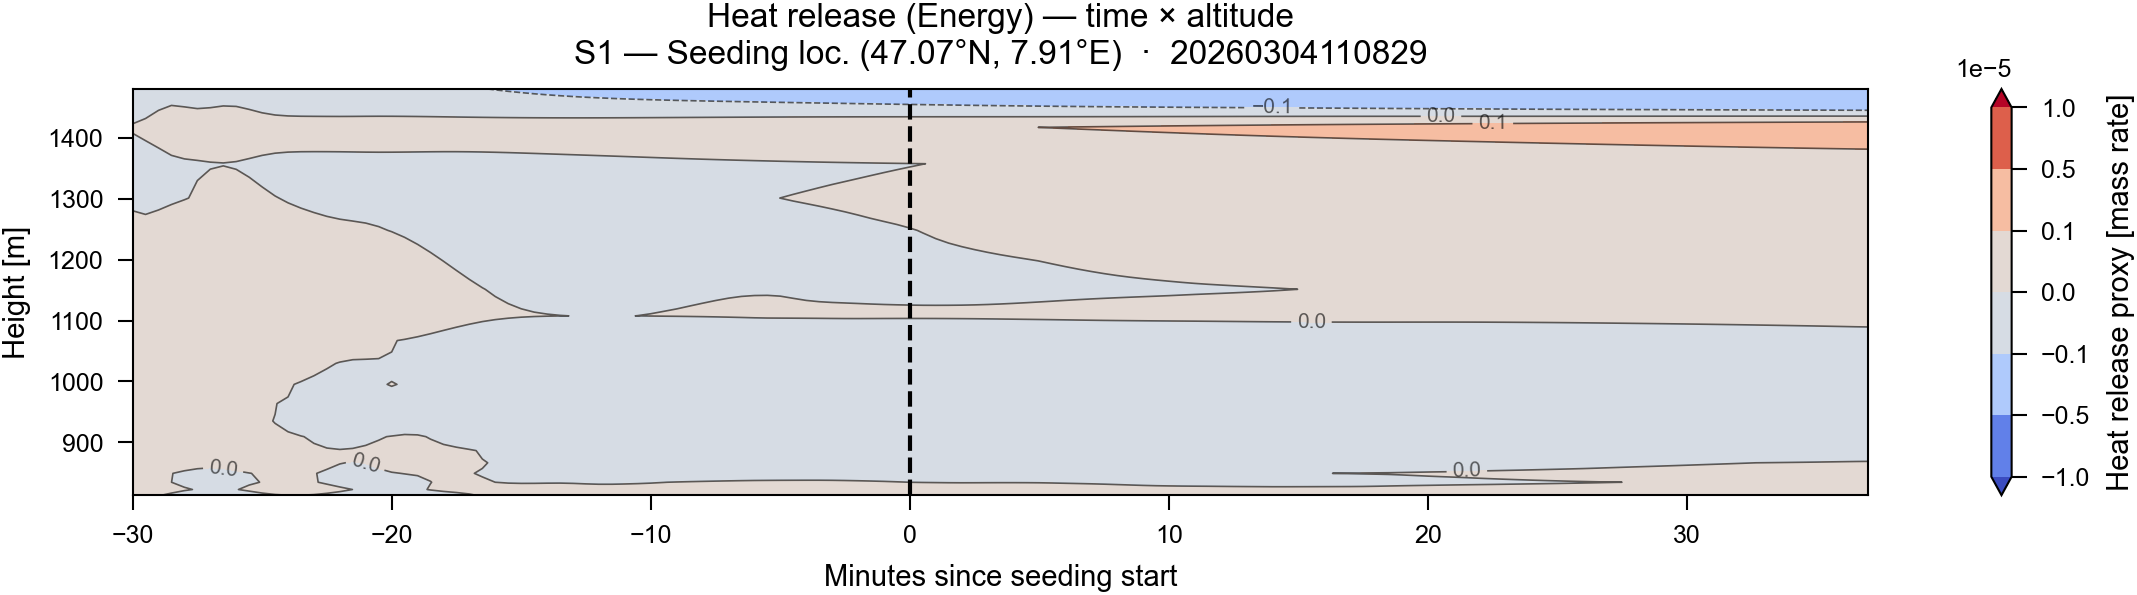

saved → ./time_height_heat_release_exp1_stn0.png


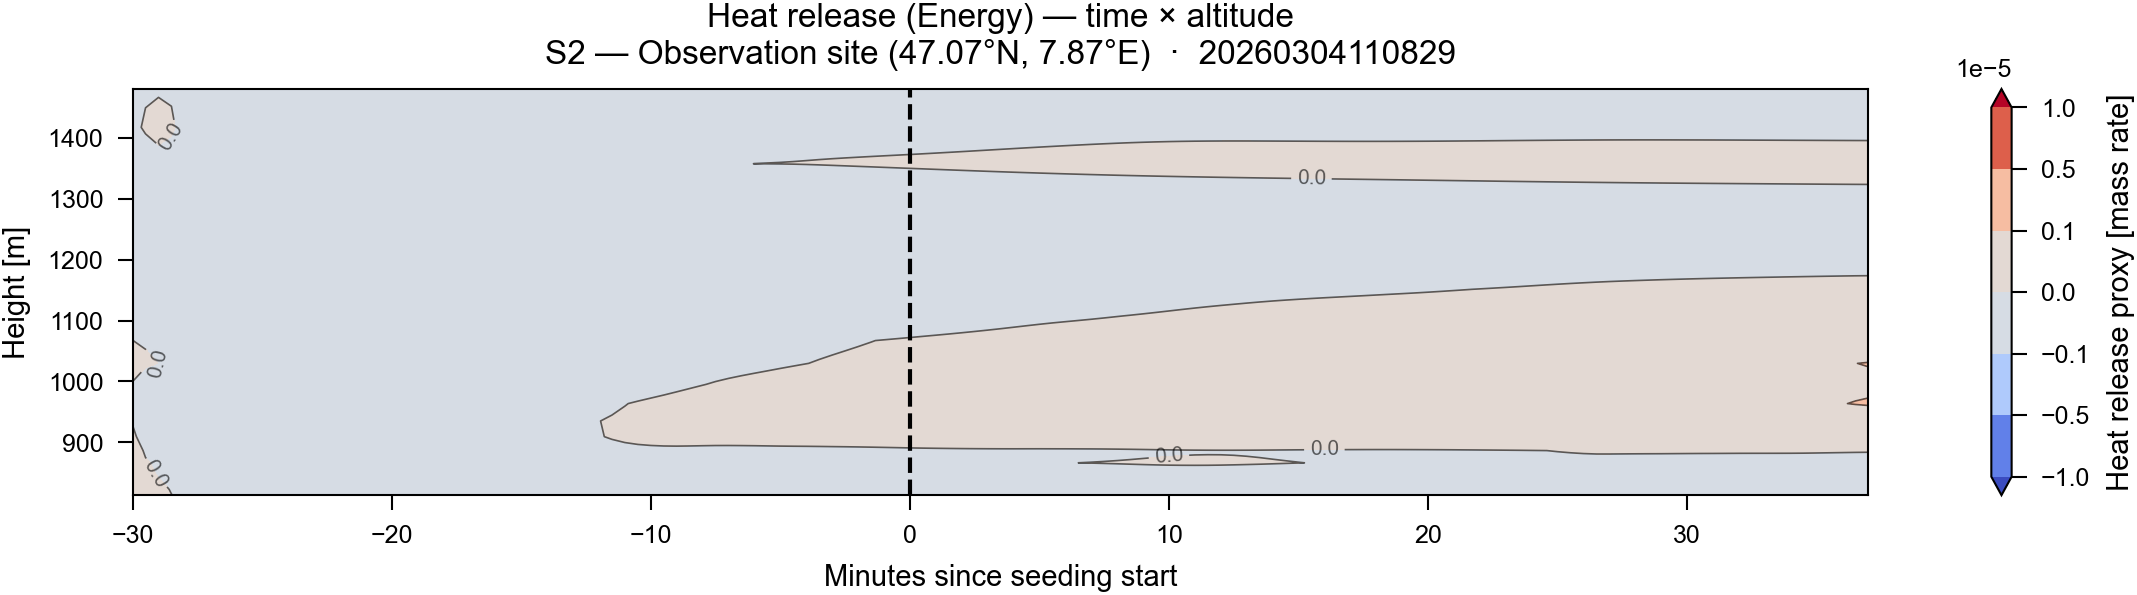

saved → ./time_height_heat_release_exp1_stn1.png


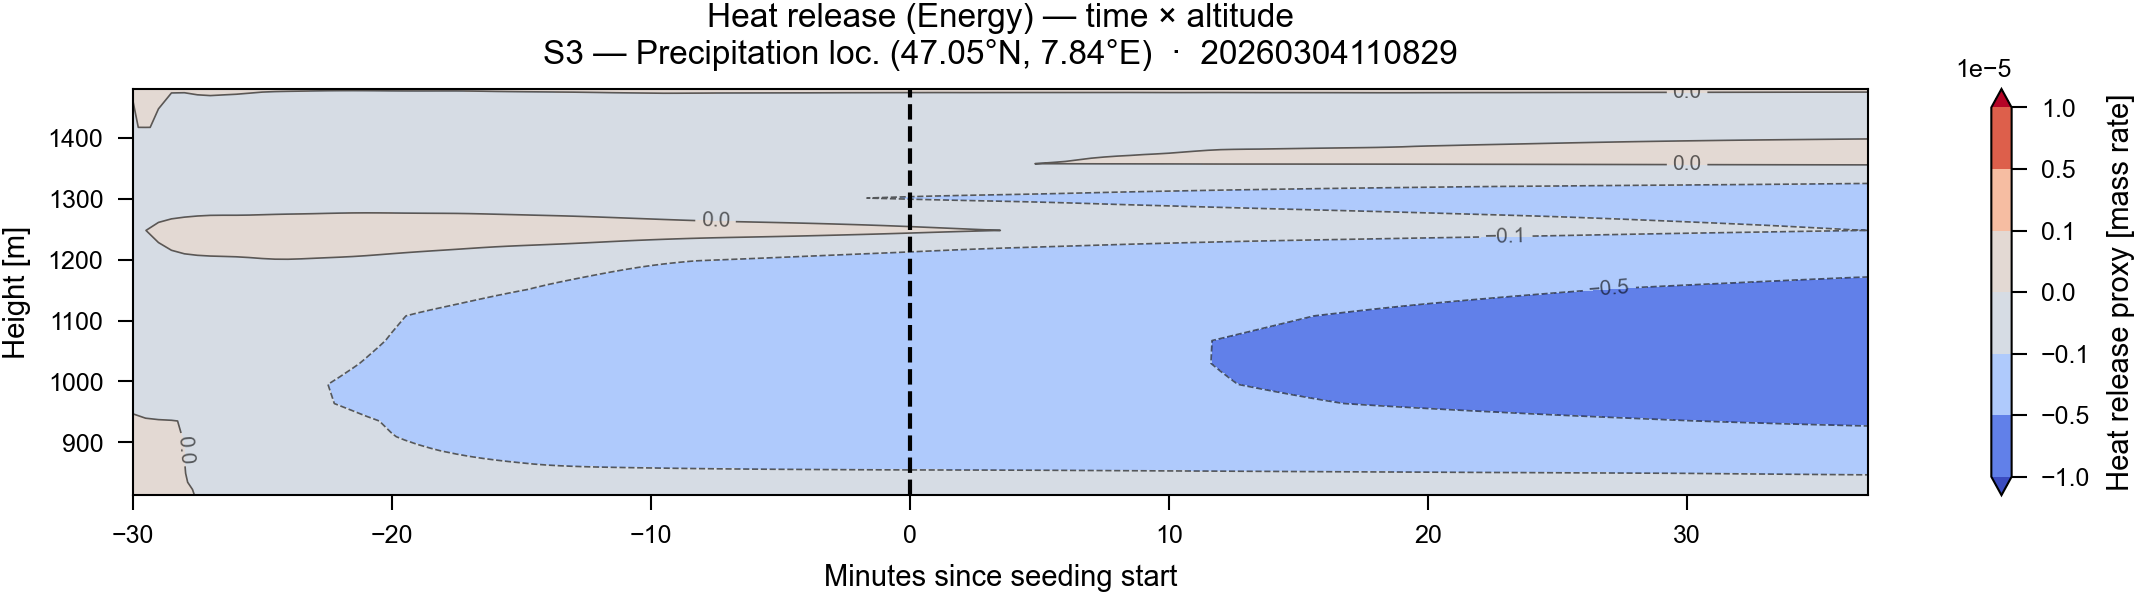

saved → ./time_height_heat_release_exp1_stn2.png


In [13]:
# Heat release (Energy): contour levels for plots with ydim = altitude (time × height). Tune as needed.
HEAT_RELEASE_LEVELS = np.array([-1e-5, -5e-6, -1e-6, 0.0, 1e-6, 5e-6, 1e-5])

def _heat_release_da(rates_Q_liq, rates_Q_ice, si):
    """Proxy for latent-heat release rate (station, time, height): positive = heating, negative = cooling.
    Sum over bins; sign: condensation/deposition/freezing = heating, melting = cooling."""
    first = next(iter(rates_Q_liq.values())) if rates_Q_liq else next(iter(rates_Q_ice.values()))
    template = first.isel(station=si)#.sum("radius_centers")
    heating = xr.zeros_like(template)
    for p, mult in [("CONDENSATION", 1), ("DEPOSITION", 1), ("REFREEZING", 1),
                    ("IMMERSION_FREEZING", 1), ("HOMOGENEOUS_FREEZING", 1), ("CONTACT_FREEZING", 1)]:
        if p in rates_Q_liq:
            heating = heating + mult * rates_Q_liq[p].isel(station=si)#.sum("bins")
        if p in rates_Q_ice:
            heating = heating + mult * rates_Q_ice[p].isel(station=si)#.sum("bins")
    for p in ["MELTING"]:
        if p in rates_Q_liq:
            heating = heating - rates_Q_liq[p].isel(station=si)#.sum("bins")
        if p in rates_Q_ice:
            heating = heating - rates_Q_ice[p].isel(station=si)#.sum("bins")
    return heating.compute()

def plot_heat_release_contour(rates_Q_liq, rates_Q_ice, si=STN_IDX, time_coarsen=TIME_COARSEN,
                              levels=None, cmap="coolwarm"):
    """Plot heat release (pos, 0, neg) as contour lines on time × altitude; ydim = altitude."""
    levels = levels if levels is not None else HEAT_RELEASE_LEVELS
    hr = _heat_release_da(rates_Q_liq, rates_Q_ice, si)
    hr_coarse = hr.resample(time=time_coarsen).mean().compute()
    t = np.asarray(hr_coarse.time.values).astype("datetime64[us]")
    t0 = np.datetime64(SEED_START).astype("datetime64[us]")
    time_min = (t - t0) / np.timedelta64(1, "m")
    height_m = hr_coarse.height_level.values
    fig, ax = plt.subplots(figsize=(FULL_COL_IN, 52 * MM), constrained_layout=True)
    cf = ax.contourf(time_min, height_m, hr_coarse.values.T, levels=levels, cmap=cmap, extend="both")
    cs = ax.contour(time_min, height_m, hr_coarse.values.T, levels=levels, colors="k", linewidths=0.4, alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=5)
    ax.axvline(0, color="k", lw=1, ls="--", label="seeding start")
    ax.set_xlabel("Minutes since seeding start")
    ax.set_ylabel("Height [m]")
    ax.set_title(f"Heat release (Energy) — time × altitude\n{stn_label(si)}  ·  {exp_label}")
    plt.colorbar(cf, ax=ax, label="Heat release proxy [mass rate]")
    plt.show()
    return fig, ax


idx_dbg = 1
if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS[:1]:
        R = rates_by_exp[eid]
        for si in PLOT_STN_IDS:
            fig, ax = plot_heat_release_contour(
                R["rates_Q_liq"], R["rates_Q_ice"], si=si, levels=HEAT_RELEASE_LEVELS)
            save_fig(fig, f"time_height_heat_release_exp{eid}_stn{si}", "png", "./")


***View B — Vertical budget profile.** Side-by-side horizontal stacked-bar charts showing the time-averaged absolute microphysical rates at each model height level. The left panel shows source (positive) contributions and the right panel shows sink (|negative|) contributions, both bin-summed over the respective spectral range. Bar thickness is proportional to the model-level spacing. Six figures are produced — one for each combination of spectrum (liquid, ice, precipitation) and tendency kind (number, mass).*

In [ ]:
# # Turbulence variable name in the dataset (e.g. TKE). Use first match if several exist.
# TURBULENCE_VAR_CANDIDATES = ["TKE", "tke", "TKE_AVG", "turbulent_kinetic_energy"]

# def _get_turbulence_da(ds, exp_idx, si, time_coarsen=TIME_COARSEN):
#     """Return turbulence DataArray (time, height) for one experiment and station, time-coarsened.
#     Uses height_level or height_level2; returns None if no turbulence var found."""
#     var_name = None
#     for v in TURBULENCE_VAR_CANDIDATES:
#         if v in ds.data_vars:
#             var_name = v
#             break
#     if var_name is None:
#         return None
#     if "expname" in ds.dims:
#         da = ds.isel(expname=exp_idx, station=si)[var_name]
#     else:
#         da = ds.isel(station=si)[var_name]
#     if "height_level2" in da.dims:
#         da = da.rename({"height_level2": "height_level"})
#     if "height_level" not in da.dims:
#         return None
#     if "time" in da.dims:
#         da = da.resample(time=time_coarsen).mean()
#     return da.compute()

# def plot_heat_release_and_turbulence(rates_Q_liq, rates_Q_ice, ds_exp, exp_idx, si=STN_IDX,
#                                      time_coarsen=TIME_COARSEN, levels=None, cmap_heat="coolwarm"):
#     """Two panels: (1) heat release time × altitude, (2) turbulence (model data) time × altitude."""
#     levels = levels if levels is not None else HEAT_RELEASE_LEVELS
#     hr = _heat_release_da(rates_Q_liq, rates_Q_ice, si)
#     hr_coarse = hr.resample(time=time_coarsen).mean().compute()
#     t = np.asarray(hr_coarse.time.values).astype("datetime64[us]")
#     t0 = np.datetime64(SEED_START).astype("datetime64[us]")
#     time_min = (t - t0) / np.timedelta64(1, "m")
#     height_m = hr_coarse.height_level.values

#     turb = _get_turbulence_da(ds_exp, exp_idx, si, time_coarsen)
#     n_panels = 2 if turb is not None else 1
#     fig, axes = plt.subplots(1, n_panels, figsize=(FULL_COL_IN, 52 * MM), sharey=(turb is None),
#                              constrained_layout=True, squeeze=False)
#     ax_heat, ax_turb = axes[0, 0], (axes[0, 1] if n_panels == 2 else None)

#     cf = ax_heat.contourf(time_min, height_m, hr_coarse.values.T, levels=levels, cmap=cmap_heat, extend="both")
#     ax_heat.contour(time_min, height_m, hr_coarse.values.T, levels=levels, colors="k", linewidths=0.4, alpha=0.6)
#     ax_heat.axvline(0, color="k", lw=1, ls="--")
#     ax_heat.set_xlabel("Minutes since seeding start")
#     ax_heat.set_ylabel("Height [m]")
#     ax_heat.set_title("Heat release (Energy)")
#     plt.colorbar(cf, ax=ax_heat, label="Heat release proxy [mass rate]")

#     if ax_turb is not None and turb is not None:
#         if "height_level" in turb.coords:
#             h_t = np.asarray(turb.height_level.values)
#         else:
#             h_t = np.arange(turb.shape[-1])
#         im = ax_turb.pcolormesh(time_min, h_t, turb.values.T, shading="auto", cmap=new_jet, norm=mcolors.LogNorm(vmin=1e-6, vmax=1e1))
#         ax_turb.axvline(0, color="k", lw=1, ls="--")
#         ax_turb.set_xlabel("Minutes since seeding start")
#         ax_turb.set_title("Turbulence (model)")
#         plt.colorbar(im, ax=ax_turb, label=turb.attrs.get("standard_name", "TKE"))

#     fig.suptitle(f"Heat release & turbulence — {stn_label(si)}  ·  {exp_label}", fontweight="semibold")
#     if turb is None:
#         fig.text(0.5, 0.02, "No turbulence variable found in dataset (TKE, tke, etc.). Heat release only.",
#                  ha="center", fontsize=6, style="italic")
#     plt.show()
#     return fig, axes



# idx_dbg = 1
# if "rates_by_exp" in dir() and rates_by_exp:
#     for eid in PLOT_EXP_IDS[:1]:
#         R = rates_by_exp[eid]
#         for si in PLOT_STN_IDS:
#             # Use full ds (has expname) so we can select turbulence for current experiment
#             ds_for_turb = ds if "ds" in dir() and "expname" in ds.dims else ds_exp
#             exp_idx = EXP_IDX if "expname" in ds_for_turb.dims else 0
#             plot_heat_release_and_turbulence(
#                 ["rates_Q_liq"], ["rates_Q_ice"], ds_for_turb, eid, si=si)
#             save_fig(fig, f"stacked_area_liquid_ice_exp{eid}_stn{si}", "png", "./")


# # if "rates_by_exp" in dir() and rates_by_exp:
# #     eid = EXP_IDX if EXP_IDX < len(rates_by_exp) else 0
# #     r = rates_by_exp[eid]
# #     # Use full ds (has expname) so we can select turbulence for current experiment
# #     ds_for_turb = ds if "ds" in dir() and "expname" in ds.dims else ds_exp
# #     exp_idx = EXP_IDX if "expname" in ds_for_turb.dims else 0
# #     plot_heat_release_and_turbulence(r["rates_Q_liq"], r["rates_Q_ice"], ds_for_turb, eid, si=si)

# # if "rates_by_exp" in dir() and rates_by_exp and EXP_IDX is not None:
# #     eid = EXP_IDX if EXP_IDX < len(rates_by_exp) else 0
# #     r = rates_by_exp[eid]
# #     # Use full ds (has expname) so we can select turbulence for current experiment
# #     ds_for_turb = ds if "ds" in dir() and "expname" in ds.dims else ds_exp
# #     exp_idx = EXP_IDX if "expname" in ds_for_turb.dims else 0
# #     plot_heat_release_and_turbulence(r["rates_Q_liq"], r["rates_Q_ice"], ds_for_turb, exp_idx, si=STN_IDX)

---

